## Cell 1 - Note

In [10]:
# ============================================================
# 05_kde_infer_aggregate.ipynb
# Final inference + confidence weighting + session aggregation
# ============================================================
#
# Inputs:
#   - pred_query.npz
#   - hybrid_transfer_best.keras
#
# Outputs:
#   - per_window_predictions.csv
#   - per_session_aggregation.csv
#   - infer_summary.json
#
# Notes:
#   - geometry comes from hybrid model outputs
#   - amplitude metadata is used for confidence weighting
#   - first version uses exponential score weighting
#   - can be upgraded later to true KDE + JS divergence
# ============================================================

## Cell 2 - Import

In [11]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

## Cell 3 - Config

In [12]:
# ============================================================
# CONFIG
# ============================================================

DATA_ROOT = Path("/home/tonyliao/Location_AMP")   # change this
BUILD_DIR = DATA_ROOT / "dataset_build_hybrid"
TRANSFER_DIR = DATA_ROOT / "hybrid_transfer_runs"
OUT_DIR = DATA_ROOT / "hybrid_infer_runs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_QUERY_NPZ = BUILD_DIR / "pred_query.npz"
MODEL_PATH = TRANSFER_DIR / "hybrid_transfer_best.keras"
LABEL_MAP_JSON = BUILD_DIR / "label_map.json"

USE_AVECSI = True
TARGET_T = 256
TARGET_S = None

# confidence weighting
CONF_MODE = "exp_score"     # "exp_score" or "exp_margin"
ALPHA_SCORE = 2.0
ALPHA_MARGIN = 4.0
MIN_WEIGHT = 1e-4

# aggregation
SESSION_KEY = "loc_dir"     # aggregate by folder/session
USE_PRESENCE_FOR_WEIGHT = True
PRESENCE_POWER = 1.0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Cell 4 - GPU Enable

In [13]:
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory growth warning:", e)

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 5 - Load Prediction

In [14]:
pred_query_obj = np.load(PRED_QUERY_NPZ, allow_pickle=True)
print("pred_query n =", len(pred_query_obj["label_id"]))

with open(LABEL_MAP_JSON, "r", encoding="utf-8") as f:
    label_meta = json.load(f)

label_map = label_meta["label_map"]
inv_label_map = {int(k): v for k, v in label_meta["inv_label_map"].items()}

NUM_CLASSES = len(label_map)
print("NUM_CLASSES =", NUM_CLASSES)
print(label_map)

pred_query n = 854
NUM_CLASSES = 9
{'Empty': 0, 'LeftDown': 1, 'LeftMid': 2, 'LeftUp': 3, 'MiddleDown': 4, 'MiddleUp': 5, 'RightDown': 6, 'RightMid': 7, 'RightUp': 8}


## Cell 6 - Helper

In [15]:
def np_load_float32(path):
    return np.load(str(path)).astype(np.float32)

def ensure_3d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:
        x = x[..., None]
    return x

def resize_to_target(x, target_t, target_s):
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    x_tf = tf.image.resize(x_tf, size=(target_t, target_s), method="bilinear")
    return x_tf.numpy().astype(np.float32)

def zscore_per_sample(x):
    mu = np.mean(x, axis=(0,1), keepdims=True)
    sd = np.std(x, axis=(0,1), keepdims=True) + 1e-6
    return ((x - mu) / sd).astype(np.float32)

def infer_target_s(npz_obj):
    a_amp = np_load_float32(npz_obj["A_amp_paths"][0])
    a_amp = ensure_3d(a_amp)
    return a_amp.shape[1]

if TARGET_S is None:
    TARGET_S = infer_target_s(pred_query_obj)

print("TARGET_T =", TARGET_T)
print("TARGET_S =", TARGET_S)

def build_amp_input_from_row(npz_obj, idx, use_avecsi=True):
    feats = []

    A = ensure_3d(np_load_float32(npz_obj["A_amp_paths"][idx]))
    B = ensure_3d(np_load_float32(npz_obj["B_amp_paths"][idx]))
    feats += [A, B]

    if use_avecsi:
        aavg_path = str(npz_obj["A_ampavg_paths"][idx])
        bavg_path = str(npz_obj["B_ampavg_paths"][idx])

        if aavg_path and bavg_path:
            Aavg = ensure_3d(np_load_float32(aavg_path))
            Bavg = ensure_3d(np_load_float32(bavg_path))

            Tref = A.shape[0]
            if Aavg.shape[0] == 1 and Tref > 1:
                Aavg = np.repeat(Aavg, Tref, axis=0)
            if Bavg.shape[0] == 1 and Tref > 1:
                Bavg = np.repeat(Bavg, Tref, axis=0)

            feats += [Aavg, Bavg]

    T0, S0 = feats[0].shape[:2]
    out = []
    for x in feats:
        if x.shape[0] != T0 or x.shape[1] != S0:
            x = resize_to_target(x, T0, S0)
        out.append(x)

    x = np.concatenate(out, axis=-1)
    x = resize_to_target(x, TARGET_T, TARGET_S)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

def build_phase_input_from_row(npz_obj, idx):
    A = ensure_3d(np_load_float32(npz_obj["A_pha_paths"][idx]))
    B = ensure_3d(np_load_float32(npz_obj["B_pha_paths"][idx]))

    T0 = max(A.shape[0], B.shape[0])
    S0 = max(A.shape[1], B.shape[1])

    if A.shape[:2] != (T0, S0):
        A = resize_to_target(A, T0, S0)
    if B.shape[:2] != (T0, S0):
        B = resize_to_target(B, T0, S0)

    x = np.concatenate([A, B], axis=-1)
    x = resize_to_target(x, TARGET_T, TARGET_S)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

CLASS_CENTER_MAP = {
    "Empty":       [0.0, 0.0],
    "LeftDown":    [2.0, 6.0],
    "LeftMid":     [2.0, 4.0],
    "LeftUp":      [2.0, 2.0],
    "MiddleDown":  [3.0, 6.0],
    "MiddleUp":    [3.0, 2.0],
    "RightDown":   [4.0, 6.0],
    "RightMid":    [4.0, 4.0],
    "RightUp":     [4.0, 2.0],
}

UNSEEN_GT_COORDS = {
    "LeftDown_Far": [0.0, 8.0],
    "LeftUp_Near": [2.0, 2.5],
    "LeftUp_Pred": [2.0, 2.0],
    # "Corner": [6.0, 0.0],
    "Wall": [6.0, 5.0],
    "Center": [3.0, 4.0],
    "Empty_Pred": [0.0, 0.0],
}

# def get_xy_from_label_name(label_name):
#     return np.asarray(CLASS_CENTER_MAP[str(label_name)], dtype=np.float32)

TARGET_T = 256
TARGET_S = 41


## Cell 7 - Load Model 

In [16]:
model = keras.models.load_model(
    MODEL_PATH,
    compile=False,
    safe_mode=False,
)

print("Loaded model:", MODEL_PATH)
model.summary()

Loaded model: /home/tonyliao/Location_AMP/hybrid_transfer_runs/hybrid_transfer_best.keras


Model: "hybrid_aoa_amp_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ amp_in (InputLayer) │ (None, 256, 41,   │          0 │ -                 │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_ssl_encoder     │ (None, 256)       │  1,308,160 │ amp_in[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pha_in (InputLayer) │ (None, 256, 41,   │          0 │ -                 │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_feat (Dense)    │ (None, 128)       │     32,896 │ amp_ssl_encoder[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phase_geometry_enc… │ (None, 128)       │  1,274,112 │ pha_in[0][0]      │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ amp_feat[0][0],   │
│ (Concatenate)       │                   │            │ phase_geometry_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_out (Dense)   │ (None, 9)         │      1,161 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ presence_out        │ (None, 1)         │        129 │ amp_feat[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ amp_feat[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 266)       │          0 │ amp_feat[0][0],   │
│ (Concatenate)       │                   │            │ phase_geometry_e… │
│                     │                   │            │ presence_out[0][… │
│                     │                   │            │ class_out[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2)         │        258 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     17,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ amp_delta_out       │ (None, 2)         │          0 │ dense_4[0][0]     │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ phase_geometry_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_gate (Dense)  │ (None, 1)         │         65 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aoa_xy_out (Dense)  │ (None, 2)         │        258 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2)         │          0 │ amp_delta_out[0]… │
│                     │                   │            │ delta_gate[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_xy_out (Add)  │ (None, 2)         │          0 │ aoa_xy_out[0][0], │
│                     │                   │            │ multiply[0][0]  

 Total params: 2,700,047 (10.30 MB)

 Trainable params: 34,181 (133.52 KB)

 Non-trainable params: 2,665,866 (10.17 MB)

## Cell 8 - Prediction Helper

In [17]:
def softmax_margin(prob):
    prob = np.asarray(prob, dtype=np.float32)
    if prob.ndim != 1:
        prob = prob.reshape(-1)

    if len(prob) < 2:
        return 0.0

    top2 = np.sort(prob)[-2:]
    return float(top2[-1] - top2[-2])

def get_scalar_meta(npz_obj, key, idx, default=np.nan):
    if key in npz_obj.files:
        return float(npz_obj[key][idx])
    return default

def compute_confidence_weight(npz_obj, idx, pred_dict):
    """
    First practical weighting version:
    1) exp_score: use window quality score + presence
    2) exp_margin: use classifier margin + presence
    """
    presence = float(pred_dict["presence"])
    class_prob = np.asarray(pred_dict["class_prob"], dtype=np.float32)

    if CONF_MODE == "exp_score":
        a_score = get_scalar_meta(npz_obj, "A_win_score", idx, default=0.0)
        b_score = get_scalar_meta(npz_obj, "B_win_score", idx, default=0.0)
        score = 0.5 * (a_score + b_score)
        w = math.exp(ALPHA_SCORE * score)

    elif CONF_MODE == "exp_margin":
        margin = softmax_margin(class_prob)
        w = math.exp(ALPHA_MARGIN * margin)

    else:
        w = 1.0

    if USE_PRESENCE_FOR_WEIGHT:
        w *= max(presence, 1e-3) ** PRESENCE_POWER

    return max(float(w), MIN_WEIGHT)

def predict_one(npz_obj, idx, model):
    amp = build_amp_input_from_row(npz_obj, idx, use_avecsi=USE_AVECSI)
    pha = build_phase_input_from_row(npz_obj, idx)

    x = {
        "amp_in": np.expand_dims(amp, axis=0),
        "pha_in": np.expand_dims(pha, axis=0),
    }

    pred = model.predict(x, verbose=0)

    out = {
        "presence": float(pred["presence_out"][0,0]),
        "class_prob": pred["class_out"][0].astype(np.float32),
        "class_id": int(np.argmax(pred["class_out"][0])),
        "class_name": inv_label_map[int(np.argmax(pred["class_out"][0]))],
        "aoa_xy": pred["aoa_xy_out"][0].astype(np.float32),
        "amp_delta": pred["amp_delta_out"][0].astype(np.float32),
        "final_xy": pred["final_xy_out"][0].astype(np.float32),
    }
    return out

example = predict_one(pred_query_obj, 0, model)
for k, v in example.items():
    print(k, v)

presence 0.9999358654022217
class_prob [7.3151226e-05 9.9908590e-01 8.5874868e-05 2.7790628e-04 4.0687562e-04
 1.4975542e-06 4.0179017e-05 1.6640309e-06 2.6941778e-05]
class_id 1
class_name LeftDown
aoa_xy [2.0062685 6.0509624]
amp_delta [-0.31683582 -0.28006327]
final_xy [2.004897  6.0497503]


## Cell 9 - Per-Window Prediction + Confidence Weighting

In [18]:
rows = []
n = len(pred_query_obj["label_id"])

for i in range(n):
    pred = predict_one(pred_query_obj, i, model)
    w = compute_confidence_weight(pred_query_obj, i, pred)

    raw_folder_name = str(pred_query_obj["raw_folder_name"][i]) if "raw_folder_name" in pred_query_obj.files else "Unknown"
    loc_dir = str(pred_query_obj["loc_dir"][i]) if "loc_dir" in pred_query_obj.files else ""
    pair_id = str(pred_query_obj["pair_id"][i]) if "pair_id" in pred_query_obj.files else str(i)

    pred_xy = np.asarray(pred["final_xy"], dtype=np.float32)
    aoa_xy = np.asarray(pred["aoa_xy"], dtype=np.float32)
    amp_delta = np.asarray(pred["amp_delta"], dtype=np.float32)

    has_gt = raw_folder_name in UNSEEN_GT_COORDS
    if has_gt:
        true_xy = np.asarray(UNSEEN_GT_COORDS[raw_folder_name], dtype=np.float32)
        err_final = float(np.linalg.norm(true_xy - pred_xy))
        err_aoa = float(np.linalg.norm(true_xy - aoa_xy))
        true_x = float(true_xy[0])
        true_y = float(true_xy[1])
    else:
        true_x = np.nan
        true_y = np.nan
        err_final = np.nan
        err_aoa = np.nan

    rows.append({
        "idx": i,
        "domain": str(pred_query_obj["domain"][i]) if "domain" in pred_query_obj.files else "pred",
        "raw_folder_name": raw_folder_name,
        "loc_dir": loc_dir,
        "pair_id": pair_id,

        "has_gt": int(has_gt),
        "true_x": true_x,
        "true_y": true_y,

        "presence": float(pred["presence"]),
        "weight": float(w),

        "pred_label_id": int(pred["class_id"]),
        "pred_label_name": str(pred["class_name"]),

        "aoa_x": float(aoa_xy[0]),
        "aoa_y": float(aoa_xy[1]),

        "delta_x": float(amp_delta[0]),
        "delta_y": float(amp_delta[1]),

        "final_x": float(pred_xy[0]),
        "final_y": float(pred_xy[1]),

        "err_aoa": err_aoa,
        "err_final": err_final,

        "A_win_score": get_scalar_meta(pred_query_obj, "A_win_score", i, default=np.nan),
        "B_win_score": get_scalar_meta(pred_query_obj, "B_win_score", i, default=np.nan),
        "A_amp_std": get_scalar_meta(pred_query_obj, "A_amp_std", i, default=np.nan),
        "B_amp_std": get_scalar_meta(pred_query_obj, "B_amp_std", i, default=np.nan),
    })

df_win = pd.DataFrame(rows)
print(df_win.shape)
display(df_win.head())

(854, 24)


,idx,domain,raw_folder_name,loc_dir,pair_id,has_gt,true_x,true_y,presence,weight,...,delta_x,delta_y,final_x,final_y,err_aoa,err_final,A_win_score,B_win_score,A_amp_std,B_amp_std
0,0,pred,LeftDown_Far,/home/tonyliao/Location_AMP/Pred/LeftDown_Far,00095,1,0.0,8.0,0.999936,3.527423,...,-0.316836,-0.280063,2.004897,6.049750,2.797117,2.796978,0.587422,0.673209,2.394551,5.210516
1,1,pred,LeftUp_Pred,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,00138,1,2.0,2.0,0.996968,3.332183,...,-0.128146,0.251187,1.835783,1.992786,0.162828,0.164375,0.599565,0.607100,2.965338,3.485685
2,2,pred,Empty_Pred,/home/tonyliao/Location_AMP/Pred/Empty_Pred,00066,1,0.0,0.0,0.005878,0.022043,...,-0.011424,0.136876,0.077062,0.023879,0.080583,0.080677,0.733099,0.588624,5.846758,1.856646
3,3,pred,LeftUp_Near,/home/tonyliao/Location_AMP/Pred/LeftUp_Near,00090,1,2.0,2.5,0.998744,3.628058,...,-0.027898,-0.034412,1.933966,1.926036,0.576963,0.577751,0.636200,0.653755,6.506658,4.341551
4,4,pred,Wall,/home/tonyliao/Location_AMP/Pred/Wall,00044,1,6.0,5.0,0.689554,2.503773,...,0.062830,0.550110,2.192813,4.114041,3.911047,3.908912,0.623859,0.665650,5.966041,4.158894


## Cell 10 - Session Aggregation Helper

In [19]:
# session-level aggregation

def weighted_xy(group_df):
    w = group_df["weight"].values.astype(np.float64)
    x = group_df["final_x"].values.astype(np.float64)
    y = group_df["final_y"].values.astype(np.float64)

    ws = np.sum(w)
    if ws <= 0:
        return float(np.mean(x)), float(np.mean(y))
    return float(np.sum(w * x) / ws), float(np.sum(w * y) / ws)

def unweighted_xy(group_df):
    return float(group_df["final_x"].mean()), float(group_df["final_y"].mean())

def majority_vote_label(group_df):
    return group_df["pred_label_name"].value_counts().idxmax()


## Cell 11 - Aggregation Weighting

In [20]:
session_rows = []

for key, g in df_win.groupby(SESSION_KEY):
    ux, uy = unweighted_xy(g)
    wx, wy = weighted_xy(g)

    raw_folder_name = g["raw_folder_name"].mode().iloc[0]
    has_gt = raw_folder_name in UNSEEN_GT_COORDS

    if has_gt:
        true_xy = np.asarray(UNSEEN_GT_COORDS[raw_folder_name], dtype=np.float32)
        err_unweighted = float(np.linalg.norm(true_xy - np.array([ux, uy], dtype=np.float32)))
        err_weighted   = float(np.linalg.norm(true_xy - np.array([wx, wy], dtype=np.float32)))
        true_x = float(true_xy[0])
        true_y = float(true_xy[1])
    else:
        err_unweighted = np.nan
        err_weighted = np.nan
        true_x = np.nan
        true_y = np.nan

    session_rows.append({
        SESSION_KEY: key,
        "raw_folder_name": raw_folder_name,
        "n_windows": int(len(g)),

        "has_gt": int(has_gt),
        "true_x": true_x,
        "true_y": true_y,

        "unweighted_x": ux,
        "unweighted_y": uy,
        "weighted_x": wx,
        "weighted_y": wy,

        "pred_label_majority": majority_vote_label(g),

        "err_unweighted": err_unweighted,
        "err_weighted": err_weighted,

        "mean_presence": float(g["presence"].mean()),
        "mean_weight": float(g["weight"].mean()),
        "mean_final_x": float(g["final_x"].mean()),
        "mean_final_y": float(g["final_y"].mean()),
        "std_final_x": float(g["final_x"].std(ddof=0)),
        "std_final_y": float(g["final_y"].std(ddof=0)),
    })

df_sess = pd.DataFrame(session_rows)
print(df_sess.shape)
display(df_sess.head())

(6, 19)


,loc_dir,raw_folder_name,n_windows,has_gt,true_x,true_y,unweighted_x,unweighted_y,weighted_x,weighted_y,pred_label_majority,err_unweighted,err_weighted,mean_presence,mean_weight,mean_final_x,mean_final_y,std_final_x,std_final_y
0,/home/tonyliao/Location_AMP/Pred/Center,Center,145,1,3.0,4.0,1.900868,5.039438,1.901940,5.040004,LeftDown,1.512786,1.512397,0.999664,3.685212,1.900868,5.039438,0.057724,0.193708
1,/home/tonyliao/Location_AMP/Pred/Empty_Pred,Empty_Pred,144,1,0.0,0.0,0.065381,0.154681,0.069519,0.161544,Empty,0.167931,0.175867,0.009625,0.032938,0.065381,0.154681,0.056770,0.106822
2,/home/tonyliao/Location_AMP/Pred/LeftDown_Far,LeftDown_Far,139,1,0.0,8.0,2.005701,5.878806,2.004851,5.875020,LeftDown,2.919298,2.921467,0.999861,3.557575,2.005701,5.878806,0.067997,0.159267
3,/home/tonyliao/Location_AMP/Pred/LeftUp_Near,LeftUp_Near,143,1,2.0,2.5,1.922849,1.949498,1.922027,1.949006,LeftUp,0.555882,0.556484,0.998218,3.603117,1.922849,1.949498,0.074640,0.088833
4,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,LeftUp_Pred,145,1,2.0,2.0,1.863380,1.993384,1.864582,1.993303,LeftUp,0.136780,0.135584,0.986311,3.384801,1.863380,1.993384,0.083950,0.083501


## Cell 13 - Summary

In [21]:
window_cls_counts = df_win["pred_label_name"].value_counts().to_dict()

summary = {
    "n_windows": int(len(df_win)),
    "n_sessions": int(len(df_sess)),
    "conf_mode": CONF_MODE,
    "alpha_score": ALPHA_SCORE,
    "alpha_margin": ALPHA_MARGIN,
    "use_presence_for_weight": USE_PRESENCE_FOR_WEIGHT,
    "presence_power": PRESENCE_POWER,
    "predicted_label_counts": window_cls_counts,
}

# only compute error summary if GT exists for some sessions
df_win_gt = df_win[df_win["has_gt"] == 1].copy()
df_sess_gt = df_sess[df_sess["has_gt"] == 1].copy()

if len(df_win_gt) > 0:
    summary["window_mean_err_final"] = float(df_win_gt["err_final"].mean())
    summary["window_median_err_final"] = float(df_win_gt["err_final"].median())

if len(df_sess_gt) > 0:
    summary["session_mean_err_unweighted"] = float(df_sess_gt["err_unweighted"].mean())
    summary["session_median_err_unweighted"] = float(df_sess_gt["err_unweighted"].median())
    summary["session_mean_err_weighted"] = float(df_sess_gt["err_weighted"].mean())
    summary["session_median_err_weighted"] = float(df_sess_gt["err_weighted"].median())

print(json.dumps(summary, indent=2))

{
  "n_windows": 854,
  "n_sessions": 6,
  "conf_mode": "exp_score",
  "alpha_score": 2.0,
  "alpha_margin": 4.0,
  "use_presence_for_weight": true,
  "presence_power": 1.0,
  "predicted_label_counts": {
    "LeftUp": 431,
    "LeftDown": 256,
    "Empty": 144,
    "LeftMid": 23
  },
  "window_mean_err_final": 1.5483713592478976,
  "window_median_err_final": 0.69963338971138,
  "session_mean_err_unweighted": 1.5657376597325008,
  "session_median_err_unweighted": 1.0343340933322906,
  "session_mean_err_weighted": 1.5707349727551143,
  "session_median_err_weighted": 1.0344401001930237
}


## Cell 14 - Result

In [22]:
print("Inference summary")
print("  n_windows :", len(df_win))
print("  n_sessions:", len(df_sess))

if "window_mean_err_final" in summary:
    print("\nGT-available window metrics")
    print("  mean final error  :", summary["window_mean_err_final"])
    print("  median final error:", summary["window_median_err_final"])

if "session_mean_err_weighted" in summary:
    print("\nGT-available session metrics")
    print("  unweighted mean   :", summary["session_mean_err_unweighted"])
    print("  unweighted median :", summary["session_median_err_unweighted"])
    print("  weighted mean     :", summary["session_mean_err_weighted"])
    print("  weighted median   :", summary["session_median_err_weighted"])

print("\nPredicted label counts")
print(summary["predicted_label_counts"])

compare_df = df_sess[[
    SESSION_KEY,
    "raw_folder_name",
    "n_windows",
    "pred_label_majority",
    "mean_presence",
    "mean_weight",
    "mean_final_x",
    "mean_final_y",
    "std_final_x",
    "std_final_y",
    "err_unweighted",
    "err_weighted",
]].copy()

compare_df = compare_df.sort_values(by="raw_folder_name").reset_index(drop=True)
display(compare_df)

Inference summary
  n_windows : 854
  n_sessions: 6

GT-available window metrics
  mean final error  : 1.5483713592478976
  median final error: 0.69963338971138

GT-available session metrics
  unweighted mean   : 1.5657376597325008
  unweighted median : 1.0343340933322906
  weighted mean     : 1.5707349727551143
  weighted median   : 1.0344401001930237

Predicted label counts
{'LeftUp': 431, 'LeftDown': 256, 'Empty': 144, 'LeftMid': 23}


,loc_dir,raw_folder_name,n_windows,pred_label_majority,mean_presence,mean_weight,mean_final_x,mean_final_y,std_final_x,std_final_y,err_unweighted,err_weighted
0,/home/tonyliao/Location_AMP/Pred/Center,Center,145,LeftDown,0.999664,3.685212,1.900868,5.039438,0.057724,0.193708,1.512786,1.512397
1,/home/tonyliao/Location_AMP/Pred/Empty_Pred,Empty_Pred,144,Empty,0.009625,0.032938,0.065381,0.154681,0.056770,0.106822,0.167931,0.175867
2,/home/tonyliao/Location_AMP/Pred/LeftDown_Far,LeftDown_Far,139,LeftDown,0.999861,3.557575,2.005701,5.878806,0.067997,0.159267,2.919298,2.921467
3,/home/tonyliao/Location_AMP/Pred/LeftUp_Near,LeftUp_Near,143,LeftUp,0.998218,3.603117,1.922849,1.949498,0.074640,0.088833,0.555882,0.556484
4,/home/tonyliao/Location_AMP/Pred/LeftUp_Pred,LeftUp_Pred,145,LeftUp,0.986311,3.384801,1.863380,1.993384,0.083950,0.083501,0.136780,0.135584
5,/home/tonyliao/Location_AMP/Pred/Wall,Wall,138,LeftUp,0.855611,3.129875,2.016271,4.023145,0.158505,0.336275,4.101748,4.122612


## Cell 15 - Plot

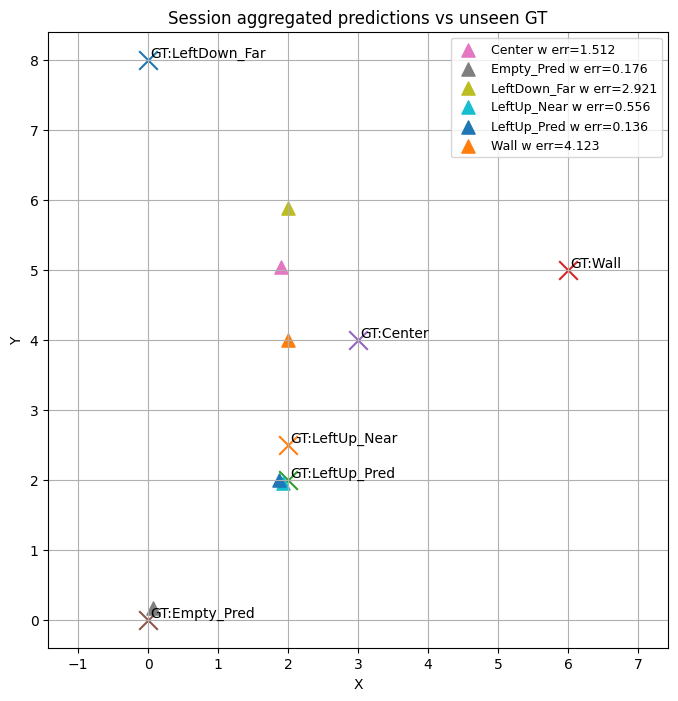

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))

# GT points
for name, xy in UNSEEN_GT_COORDS.items():
    plt.scatter(xy[0], xy[1], marker="x", s=180)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, f"GT:{name}")

# aggregated predictions with error in legend
for _, row in df_sess.iterrows():
    name = row["raw_folder_name"]

    # plt.scatter(
    #     row["unweighted_x"],
    #     row["unweighted_y"],
    #     s=90,
    #     marker="o",
    #     label=f"{name} uw err={row['err_unweighted']:.3f}" if not np.isnan(row["err_unweighted"]) else f"{name} uw"
    # )

    plt.scatter(
        row["weighted_x"],
        row["weighted_y"],
        s=90,
        marker="^",
        label=f"{name} w err={row['err_weighted']:.3f}" if not np.isnan(row["err_weighted"]) else f"{name} w"
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Session aggregated predictions vs unseen GT")
plt.grid(True)
plt.axis("equal")
plt.legend(fontsize=9, loc="best")
plt.show()

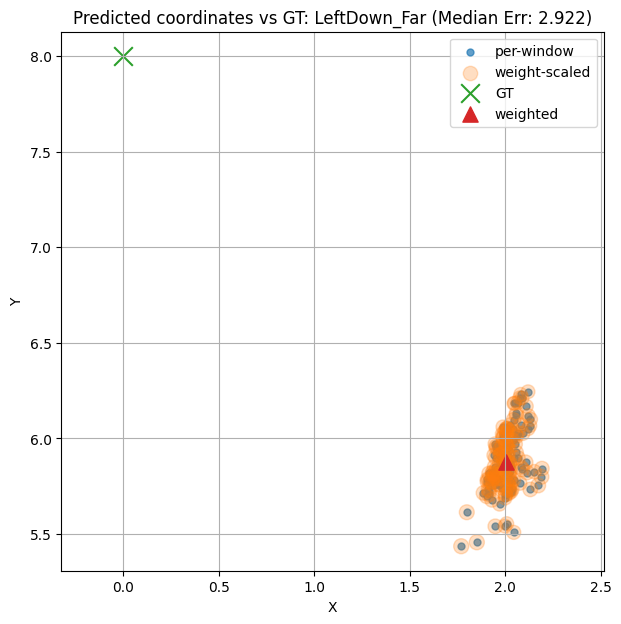

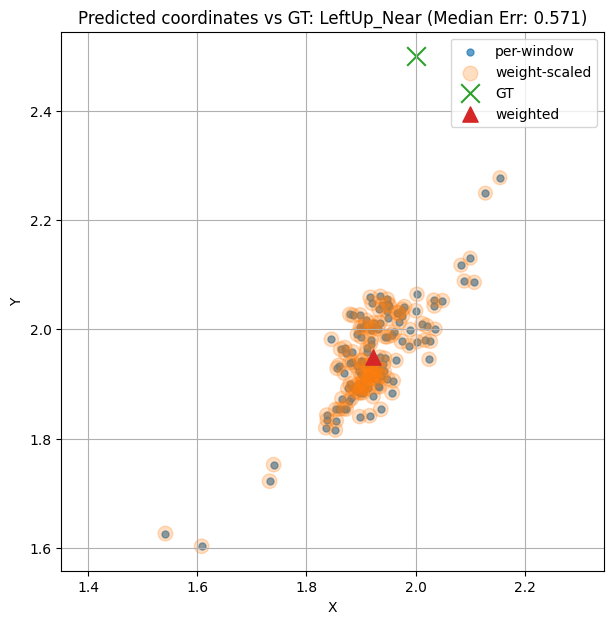

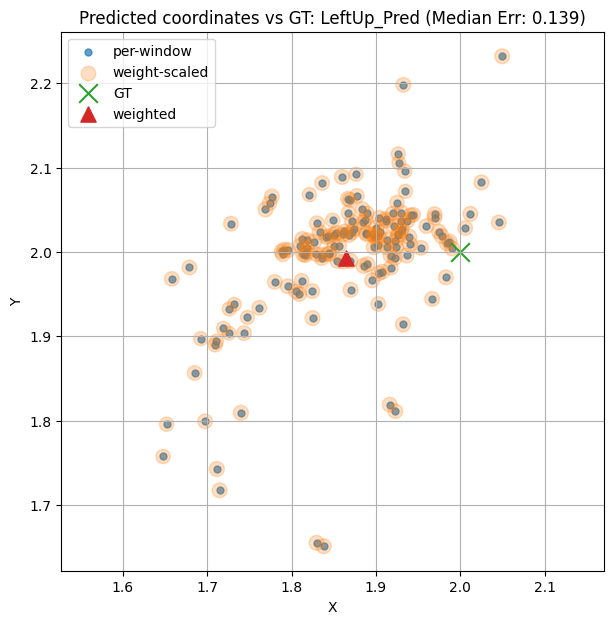

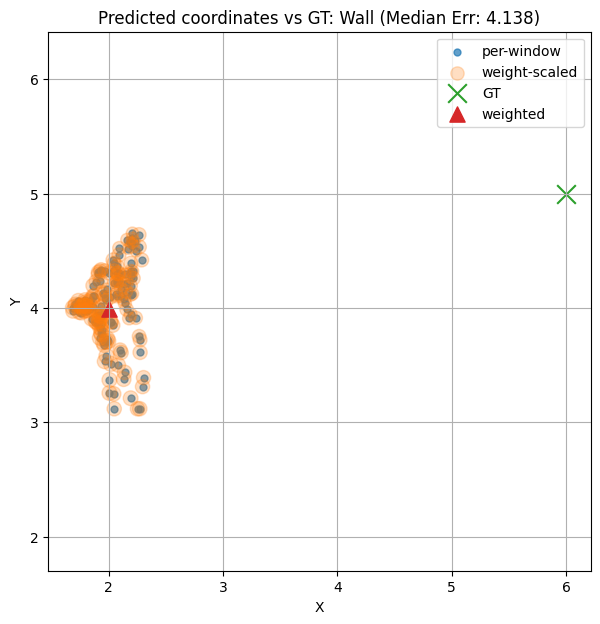

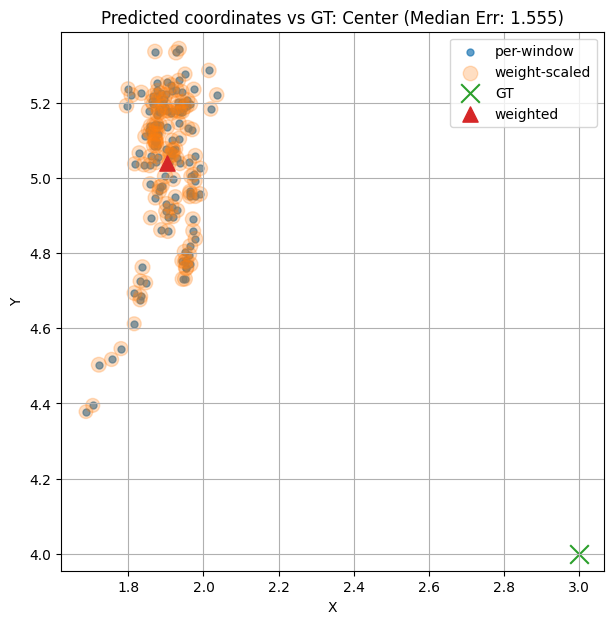

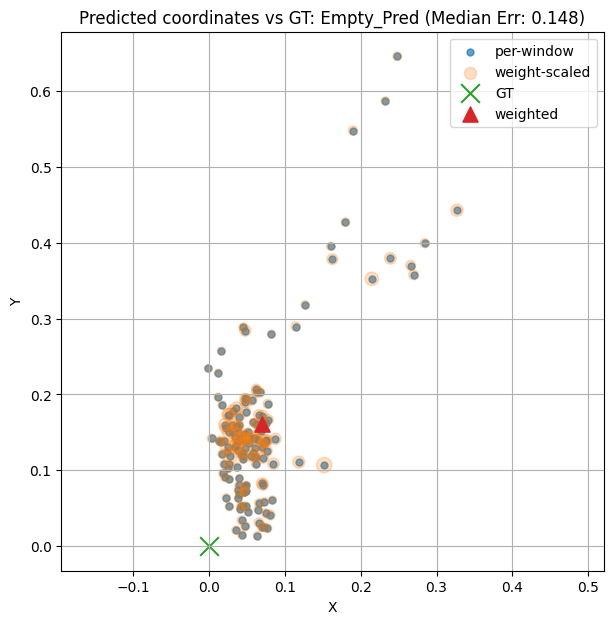

In [24]:
for session_name in UNSEEN_GT_COORDS.keys():
    g = df_win[df_win["raw_folder_name"] == session_name].copy()
    sess = df_sess[df_sess["raw_folder_name"] == session_name].iloc[0]
    gt = np.array(UNSEEN_GT_COORDS[session_name], dtype=np.float32)

    # Compute medium_err_final for this session
    mse = g["err_final"].median()

    plt.figure(figsize=(7, 7))

    plt.scatter(g["final_x"], g["final_y"], s=25, alpha=0.7, label="per-window")

    w_norm = g["weight"] / g["weight"].max()
    plt.scatter(
        g["final_x"],
        g["final_y"],
        s=20 + 100 * w_norm,
        alpha=0.25,
        label="weight-scaled"
    )

    plt.scatter(gt[0], gt[1], marker="x", s=180, label="GT")
    # plt.scatter(sess["unweighted_x"], sess["unweighted_y"], s=120, marker="o", label="unweighted")
    plt.scatter(sess["weighted_x"], sess["weighted_y"], s=120, marker="^", label="weighted")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Predicted coordinates vs GT: {session_name} (Median Err: {mse:.3f})")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.show()

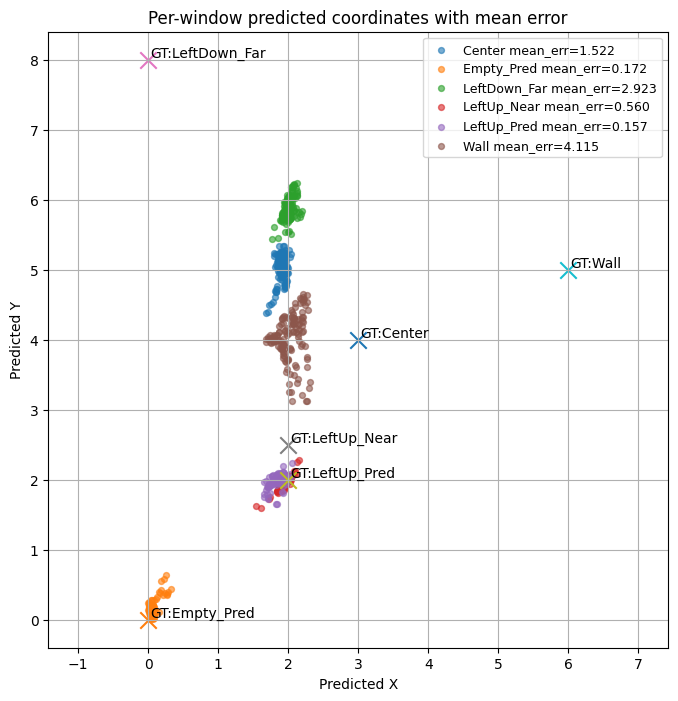

In [25]:
plt.figure(figsize=(8, 8))

for raw_name, g in df_win.groupby("raw_folder_name"):
    mean_err = g["err_final"].mean() if "err_final" in g.columns else np.nan

    label_txt = f"{raw_name} mean_err={mean_err:.3f}" if not np.isnan(mean_err) else raw_name

    plt.scatter(
        g["final_x"],
        g["final_y"],
        s=18,
        alpha=0.6,
        label=label_txt
    )

for name, xy in UNSEEN_GT_COORDS.items():
    plt.scatter(xy[0], xy[1], marker="x", s=140)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, f"GT:{name}")

plt.xlabel("Predicted X")
plt.ylabel("Predicted Y")
plt.title("Per-window predicted coordinates with mean error")
plt.grid(True)
plt.axis("equal")
plt.legend(fontsize=9)
plt.show()

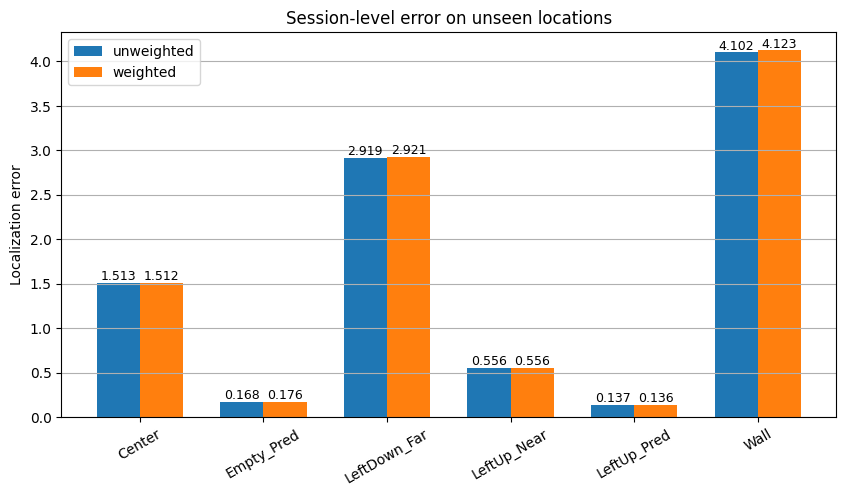

In [26]:
err_plot_df = df_sess[["raw_folder_name", "err_unweighted", "err_weighted"]].copy()
err_plot_df = err_plot_df.sort_values("raw_folder_name").reset_index(drop=True)

x = np.arange(len(err_plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(x - width/2, err_plot_df["err_unweighted"], width, label="unweighted")
bars2 = plt.bar(x + width/2, err_plot_df["err_weighted"], width, label="weighted")

plt.xticks(x, err_plot_df["raw_folder_name"], rotation=30)
plt.ylabel("Localization error")
plt.title("Session-level error on unseen locations")
plt.legend()
plt.grid(True, axis="y")

for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=9)

plt.show()

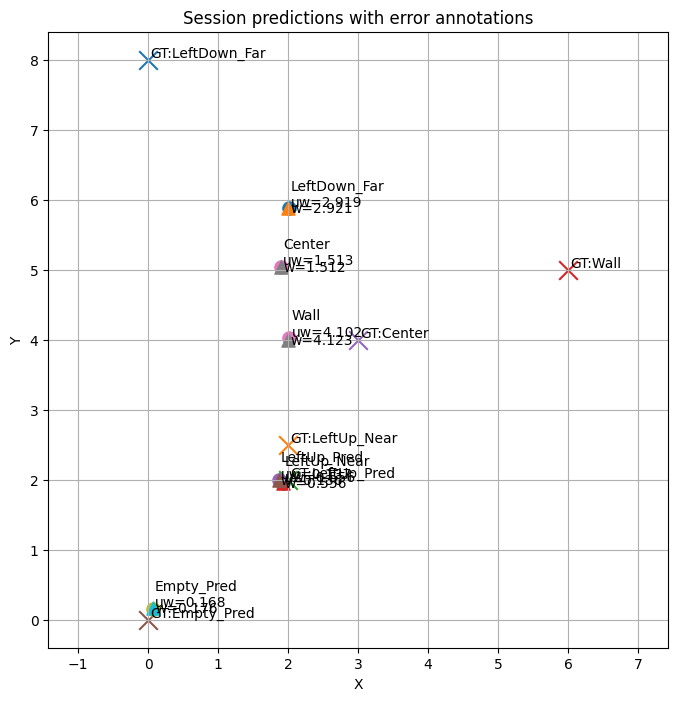

In [27]:
plt.figure(figsize=(8, 8))

for name, xy in UNSEEN_GT_COORDS.items():
    plt.scatter(xy[0], xy[1], marker="x", s=180)
    plt.text(xy[0] + 0.03, xy[1] + 0.03, f"GT:{name}")

for _, row in df_sess.iterrows():
    name = row["raw_folder_name"]

    plt.scatter(row["unweighted_x"], row["unweighted_y"], s=90, marker="o")
    plt.text(
        row["unweighted_x"] + 0.03,
        row["unweighted_y"] + 0.03,
        f"{name}\nuw={row['err_unweighted']:.3f}"
    )

    plt.scatter(row["weighted_x"], row["weighted_y"], s=90, marker="^")
    plt.text(
        row["weighted_x"] + 0.03,
        row["weighted_y"] - 0.06,
        f"w={row['err_weighted']:.3f}"
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Session predictions with error annotations")
plt.grid(True)
plt.axis("equal")
plt.show()

In [28]:
# import tensorflow as tf
# tf.keras.backend.clear_session()
# #Restart the kernel to free memory
# import IPython
# app = IPython.get_ipython()
# app.kernel.do_shutdown(True)  # True = restart, False = shutdown